# more numpy
A few more topics in somewhat random order

## Reading and writing files
Reading data from *text* files is relatively straightforward. We'll see later how to handle some other types of files.


In [ ]:
import numpy as np
A2 = np.array([[1, 2, 3], [4, 5, 6]])
np.savetxt('testfile.txt', A2)
np.savetxt('testfile.csv', A2, delimiter=',', header='col1, col2, col3')

# use the help for more options and their meaning 
# help(np.savetxt) 

Conversely, we can import data from text files: 

In [ ]:
grades = np.loadtxt('grades.csv', skiprows = (1), usecols = (9), delimiter = ',')
print(grades)

## Random numbers
`np.random` gives access to several types of random number generators. Some of the most relevant are
* `np.random.uniform`: uniformly distributed numbers
* `np.random.normal`: a 'normal' distribute ("bell curve")

In [ ]:
unif = np.random.uniform(low = -10, high = 10, size = (3,4))
print(unif)


mean = 0
stddev = 5
normal = np.random.normal(0, 5, size=(3,4))
print(normal)

visualizing the difference:

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
n = 501
X = np.random.uniform(low= -1, high = 1, size =(n,))
Y = np.random.uniform(low= -1, high = 1, size =(n,))
ax.scatter(X,Y, color='b', label = 'Uniform')
X = np.random.normal(loc= 0, scale = 0.25, size =(n,))
Y = np.random.normal(loc= 0, scale = 0.25, size =(n,))
ax.scatter(X,Y, color='r', label = 'normal')
ax.set_aspect('equal', 'box')
ax.legend()

## Application: A very inefficient away to compute $\pi$.
The idea of the Monte Carlo method to compute $\pi$ is to estimate the probability that a point with uniform random coordinates in (-1,1) is in the circle of diameter 1 is proportional to the ratio of the area of the circle over the square, $\pi/4$

In [ ]:
npoints = 1000
ntries = 10
for j in range(ntries):
    XY = np.random.uniform(low = -2, high = 2, size = (npoints, 2))
    insidePoints = [xy for xy in XY if xy[0]**2 + xy[1]**2 <= 1 ]
    outsidePoints = [xy for xy in XY if xy[0]**2 + xy[1]**2 > 1 ]
    piApprox = 16 * len(insidePoints) / npoints
    print(f"After {npoints} trials, pi ~ {piApprox} (error {100*abs((np.pi-piApprox)/np.pi):.2f}%)")


In [ ]:
# Same thing with a plot
npoints = 10000
fig, ax = plt.subplots()
XY = np.random.uniform(low = -2, high = 2, size = (npoints, 2))
insidePoints = np.array([xy for xy in XY if xy[0]**2 + xy[1]**2 <= 1 ])
outsidePoints = np.array([xy for xy in XY if xy[0]**2 + xy[1]**2 > 1 ])
piApprox = 16 * len(insidePoints) / npoints
print(f"After {npoints} trials, pi ~ {piApprox} (error {100*abs((np.pi-piApprox)/np.pi):.2f}%)")

ax.scatter(insidePoints[:,0], insidePoints[:,1], color = 'r')
ax.scatter(outsidePoints[:,0], outsidePoints[:,1], color = 'b')
# ax.axis([-1.1, 1.1, -1.1, 1.1])
ax.set_aspect('equal', 'box')


# Tuesday July 28th 2026

## Announcements 
- Test 2 this Thursday July 30th at 10:30am
    - 60 minute test
    - Practice test posted on Avenue
- Assignment 3 due on Friday at 11:59pm

## Last time
- Introduction to Numpy as arrays
- Array based programming (vectorization)

In [1]:
import numpy as np

### Review of Array based programming

Numpy introduces a new data type to Python called an $n$-dimensional array. We can view nd-arrays as a better implementation of matrices as opposed to nested lists. However, nd-arrays also have the advantage of **vectorization**. For example, the definitions of the following operations differ.

In [2]:
A = [1,2,3]
B = [4,5,6]

Anp = np.array([1,2,3])
Bnp = np.array([4,5,6])

print(f"A + B = {A + B}")
print(f"Anp + Bnp = {Anp + Bnp}")

A + B = [1, 2, 3, 4, 5, 6]
Anp + Bnp = [5 7 9]


This has many interesting uses, namely, when we want to preform uniform operations on all of our data without losing time through iteration.

For example:

In [3]:
A = []

for i in range(100_000_000):
    if i % 7 == 0 and i % 5 != 0:
        A += [2*i]
    else:
        A += [i]

In [4]:
B = np.arange(100_000_000)
B[(B % 7 == 0) * (B % 5 != 0)] *= 2

## Warmup exercise

**Fact:** Let $A\subseteq [0,1]$ denote a random set of numbers contained in the interval $[0,1]$ (as viewed as a subset of the real numbers). Consider the following process: Choose elements at random from $A$ and keep track of their running sum, stop when the sum excedes one. It turns out that this process will on average take exactly $e$ steps. Write some code to verify this!

In [15]:
max_trials = 10_000
num_trials = 0
num_steps_trial = []
while num_trials < max_trials:  
    A = np.random.uniform(low = 0, high =1,size = (100))
    run_sum = 0
    steps = 0
    for a in np.nditer(A):
        run_sum += a
        steps +=1
        if run_sum > 1:
            break
    num_steps_trial += [steps]
    num_trials += 1

print(sum(num_steps_trial)/len(num_steps_trial))
print(np.exp(1))

2.7283
2.718281828459045


In [ ]:
max_trials = 1000
trial_length = []
i = 0
while i <= max_trials:
    A = np.random.uniform(low = 0, high = 1, size  = (100_000))
    run_sum = 0
    steps = 0
    for a in np.nditer(A):
        run_sum += a
        steps +=1
        if run_sum > 1:
            break
    trial_length += [steps]
    i+=1

print(sum(trial_length)/len(trial_length))


## Exercise 2


In [34]:
# Consider the following "deck" of cards

deck = np.array([2,2,2,2,3,3,3,3,4,4,4,4,5,5,5,5,6,6,6,6,7,7,7,7,8,8,8,8,9,9,9,9])

# We can shuffle the deck by using np.random.shuffle
#print(deck)

# Approximate the probability that you will find a pair of 2's next to each other after suffling
max_num_trials = 1000
trial_num = 0
trial_data = []

while trial_num < max_num_trials:
    np.random.shuffle(deck)
    pair1 = deck[1:]
    pair2 = deck[:-1]

    num_pairs_2 = ((pair1 == 2) * (pair2 == 2)).sum()
    trial_data += [num_pairs_2]
    trial_num += 1

avg_num_2 = sum(trial_data)/len(trial_data)
print(avg_num_2)
# What about a tripple of 3's?

0.361


## The `polynomial` class
In assignment 3, you are implementing polynomial operations. `numpy` contains all of these operations (but you are of course not allowed to use them in the assignment...)

`np.polynomial` introduces a new python type representing a polynomial from its coefficients: `np.polynomial.Polynomial` and a long list of *methods*:
* evaluation: `P(1)`
* algebraic operations: `+`, `-`, `*`
* derivative: `P.deriv()`
* antiderivative: `P.integ()`
* roots: `P.roots()`
* construction from roots: `P.fromroots()`
* see a longer list using python help


In [36]:
P = np.polynomial.Polynomial([1, 2, 3])
print(P)

print(P(0))
print(P*P)
print(P.deriv())

1.0 + 2.0·x + 3.0·x²
1.0
1.0 + 4.0·x + 10.0·x² + 12.0·x³ + 9.0·x⁴
2.0 + 6.0·x


In [38]:
import matplotlib.pyplot as plt

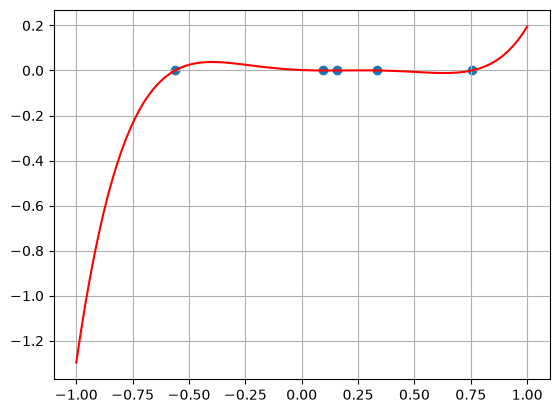

In [40]:
n = 5
X = np.random.uniform(low = -1, high = 1, size = n)
P = np.polynomial.Polynomial.fromroots(X)

fig, ax = plt.subplots()
ax.scatter(X, np.zeros(n))
xplot = np.linspace(-1, 1,101)
ax.plot(xplot, P(xplot), color = 'red')
ax.grid()


0.10088308 - 0.23480808·x


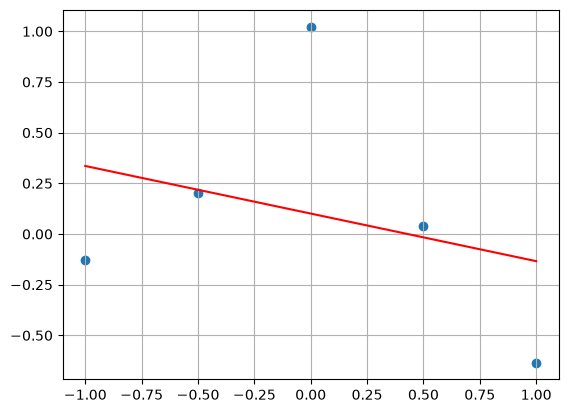

In [43]:
n = 5
X = np.linspace(-1, 1, n)
Y = np.random.uniform(low = -2, high = 2, size = n)
P = np.polynomial.Polynomial.fit(X,Y,1)
print(P)

fig, ax = plt.subplots()
ax.scatter(X, Y)
xplot = np.linspace(-1, 1,101)
ax.plot(xplot, P(xplot), color = 'red')
ax.grid()
